## **Load model, data etc and prepare for evaluation**

In [1]:
import torch
import pandas as pd
from torch.utils.data import DataLoader
from tqdm import tqdm

from CNN import InfernoCalibNet, ChestXRayDataset, CALIB_DIR

def evaluate_inferno_logits(dataset_csv, model_weights_path):
    torch.cuda.empty_cache()

    df_meta = pd.read_csv(dataset_csv)
    dataset = ChestXRayDataset(dataset_csv, transform=False)
    data_loader = DataLoader(
        dataset, batch_size=32, shuffle=False, num_workers=8, pin_memory=True
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = InfernoCalibNet(num_classes=2, model_type="resnet34").to(device)
    model.load_state_dict(torch.load(model_weights_path, weights_only=True))
    model.eval()

    preds_list = []
    targets_list = []

    with torch.no_grad():
        for inputs, targets in tqdm(data_loader, desc="Evaluating", leave=False):
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            preds_list.append(outputs.cpu())
            targets_list.append(targets.cpu())

    preds_tensor = torch.cat(preds_list)
    targets_tensor = torch.cat(targets_list)

    df_meta = df_meta.reset_index(drop=True)
    df_meta["LOGIT_EFFUSION"] = preds_tensor[:, 0].numpy()
    df_meta["LABEL_EFFUSION"] = targets_tensor[:, 0].numpy().astype(int)
    df_meta["LOGIT_ATELECTASIS"] = preds_tensor[:, 1].numpy()
    df_meta["LABEL_ATELECTASIS"] = targets_tensor[:, 1].numpy().astype(int)

    loss_fn = torch.nn.BCEWithLogitsLoss()
    avg_loss = loss_fn(preds_tensor, targets_tensor).item()

    return df_meta, preds_tensor, targets_tensor, avg_loss

df_train, preds_train, targets_train, loss_train = evaluate_inferno_logits(CALIB_DIR / "calibration_train.csv", CALIB_DIR / "InfernoCalibNetML.pth")
df_test, preds_test, targets_test, loss_test = evaluate_inferno_logits(CALIB_DIR / "calibration_test.csv", CALIB_DIR / "InfernoCalibNetML.pth")


## **Evaluation script with utility matrix for multilabel predictions**

────────────────────────────────────────── Threshold Search on Train Set ──────────────────────────────────────────

Train BCEWithLogitsLoss: 0.4271

Utility Score at Threshold 0.50: 0.9036

Best Threshold for Utility: 0.33

Max Average Utility Score (Train Set): 0.9183

───────────────────────────────────────────── Evaluation on Test Set ──────────────────────────────────────────────

Test BCEWithLogitsLoss: 0.4482

Average Utility Score (Test Set): 0.9136

                              Classification Metrics                                               
                ┏━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┓                
                ┃    Label    ┃ Precision ┃ Recall ┃ F1-score ┃ Accuracy ┃  AUROC ┃ Avg Precision ┃                
                ┡━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━┩                
                │  Effusion   │    0.6858 │ 0.8009 │   0.7389 │   0.8266 │ 0.8834 │        0.7655 │                
                ├─────────────┼───────────┼────────┼──────────┼──────────┼────────┼───────────────┤                
                │ Atelectasis │    0.5285 │ 0.6843 │   0.5964 │   0.7245 │ 0.7825 │        0.6057 │                
                └─────────────┴───────────┴────────┴──────────┴──────────┴────────┴───────────────┘

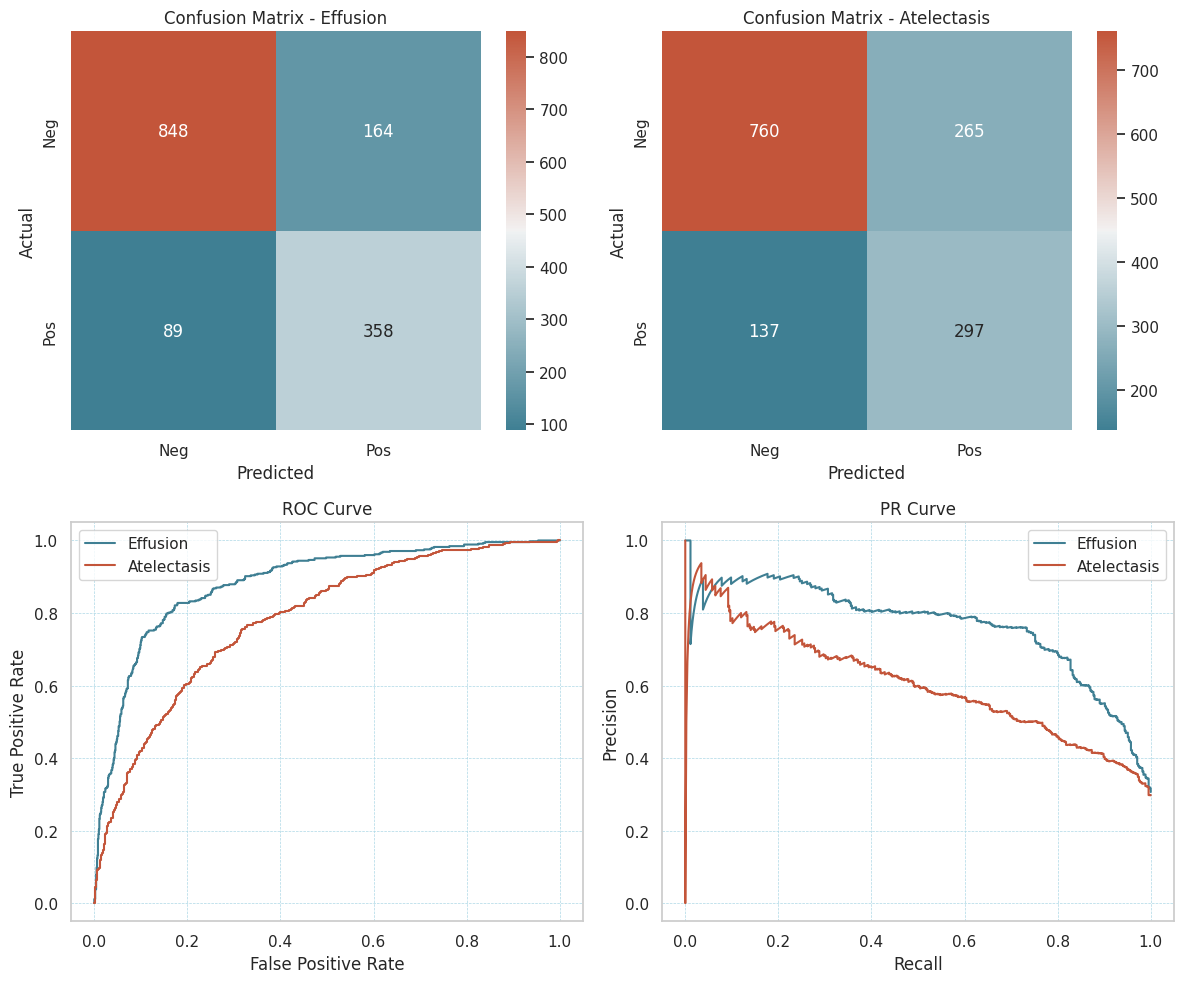

In [2]:
import torch
import numpy as np
import seaborn as sns
from rich.table import Table
import matplotlib.pyplot as plt
from rich.console import Console

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)

sns.set_theme(style="whitegrid", palette=sns.diverging_palette(220, 20, n=2))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

console = Console()

utility_matrix = np.array([
    [1.00, 0.55, 0.60, 0.40],
    [0.90, 1.00, 0.65, 0.75],
    [0.90, 0.65, 1.00, 0.75],
    [0.80, 0.85, 0.85, 1.00],
])

label_index = lambda e, a: e + 2 * a

def find_best_threshold(preds_tensor, targets_tensor, avg_loss):
    probs = torch.sigmoid(preds_tensor).numpy()
    targets = targets_tensor.numpy()

    console.rule("[bold cyan]Threshold Search on Train Set")
    console.print(f"Train BCEWithLogitsLoss: {avg_loss:.4f}")

    thresholds = np.linspace(0.1, 0.9, 81)
    best_utility = -1
    best_threshold = 0.5

    for threshold in thresholds:
        decisions_util = []
        true_vals_util = []
        for prob_vec, true_vec in zip(probs, targets):
            pred_bin = (prob_vec > threshold).astype(int)
            true_bin = true_vec.astype(int)

            pred_idx = int(label_index(pred_bin[0], pred_bin[1]))
            true_idx = int(label_index(true_bin[0], true_bin[1]))

            decisions_util.append(pred_idx)
            true_vals_util.append(true_idx)

        avg_utility = np.mean([utility_matrix[p, t] for p, t in zip(decisions_util, true_vals_util)])

        if avg_utility > best_utility:
            best_utility = avg_utility
            best_threshold = threshold

        if threshold == 0.5:
            console.print(f"[bold cyan]Utility Score at Threshold 0.50: {avg_utility:.4f}")

    console.print(f"\n[bold yellow]Best Threshold for Utility: {best_threshold:.2f}")
    console.print(f"[bold green]Max Average Utility Score (Train Set): {best_utility:.4f}")

    return best_threshold

def evaluate_at_threshold(preds_tensor, targets_tensor, best_threshold, avg_loss):
    probs = torch.sigmoid(preds_tensor).numpy()
    targets = targets_tensor.numpy()

    console.rule("[bold cyan]Evaluation on Test Set")
    console.print(f"Test BCEWithLogitsLoss: {avg_loss:.4f}")

    decisions_util = []
    true_vals_util = []
    for prob_vec, true_vec in zip(probs, targets):
        pred_bin = (prob_vec > best_threshold).astype(int)
        true_bin = true_vec.astype(int)

        pred_idx = int(label_index(pred_bin[0], pred_bin[1]))
        true_idx = int(label_index(true_bin[0], true_bin[1]))

        decisions_util.append(pred_idx)
        true_vals_util.append(true_idx)

    avg_utility = np.mean([utility_matrix[p, t] for p, t in zip(decisions_util, true_vals_util)])
    console.print(f"[bold green]Average Utility Score (Test Set): {avg_utility:.4f}\n")

    table = Table(title="Classification Metrics", show_lines=True)
    table.add_column("Label", justify="center")
    table.add_column("Precision", justify="right")
    table.add_column("Recall", justify="right")
    table.add_column("F1-score", justify="right")
    table.add_column("Accuracy", justify="right")
    table.add_column("AUROC", justify="right")
    table.add_column("Avg Precision", justify="right")

    roc_data = {}
    pr_data = {}
    confusion_matrices = {}

    for i, label_name in zip([0, 1], ["Effusion", "Atelectasis"]):
        p = probs[:, i] > best_threshold
        t = targets[:, i]

        prec = precision_score(t, p)
        rec = recall_score(t, p)
        f1 = f1_score(t, p)
        acc = accuracy_score(t, p)
        auroc = roc_auc_score(t, probs[:, i])
        ap = average_precision_score(t, probs[:, i])

        table.add_row(label_name, f"{prec:.4f}", f"{rec:.4f}", f"{f1:.4f}", f"{acc:.4f}", f"{auroc:.4f}", f"{ap:.4f}")

        fpr, tpr, _ = roc_curve(t, probs[:, i])
        prec_curve, rec_curve, _ = precision_recall_curve(t, probs[:, i])

        roc_data[label_name] = (fpr, tpr)
        pr_data[label_name] = (rec_curve, prec_curve)

        cm = confusion_matrix(t, p)
        confusion_matrices[label_name] = cm

    console.print(table, justify="center")

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    for idx, (label, cm) in enumerate(confusion_matrices.items()):
        ax = axes[0, idx]
        sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"], ax=ax)
        ax.set_title(f"Confusion Matrix - {label}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    for idx, (label, (fpr, tpr)) in enumerate(roc_data.items()):
        axes[1, 0].plot(fpr, tpr, label=label)
    axes[1, 0].set_title("ROC Curve")
    axes[1, 0].set_xlabel("False Positive Rate")
    axes[1, 0].set_ylabel("True Positive Rate")
    axes[1, 0].legend()
    axes[1, 0].grid(True, linestyle='--', linewidth=0.5, color='lightblue')

    for idx, (rec_curve, prec_curve) in enumerate(pr_data.values()):
        axes[1, 1].plot(rec_curve, prec_curve, label=list(pr_data.keys())[idx])
    axes[1, 1].set_title("PR Curve")
    axes[1, 1].set_xlabel("Recall")
    axes[1, 1].set_ylabel("Precision")
    axes[1, 1].legend()
    axes[1, 1].grid(True, linestyle='--', linewidth=0.5, color='lightblue')

    plt.tight_layout()
    plt.show()

best_thresh = find_best_threshold(preds_train, targets_train, loss_train)
evaluate_at_threshold(preds_test, targets_test, best_thresh, loss_test)

## **Evaluate (eMatrix) Inferno Improvement**

| ⚙️ **Method**                    | ✅ **Advantages**                                                                                          | ❌ **Disadvantages**                                                                                   |
|----------------------------------|-------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------|
| 🧮 **Fixed Threshold (e.g., 0.5)** | - Very simple and fast<br>- Easy to implement and explain<br>- No additional computation required           | - Same threshold for all labels<br>- Ignores class imbalance<br>- Ignores prediction uncertainty<br>- No adaptation to task-specific costs |
| 🎯 **Per-Label Threshold Search**  | - Tailors threshold per label<br>- Can incorporate task-specific utility via validation<br>- Usually better than fixed threshold | - Treats labels independently<br>- Still relies on point estimates<br>- Slower due to validation loop |
| 🧠 **Inferno (Expected Utility)**  | - Makes joint predictions<br>- Incorporates uncertainty<br>- Uses full predictive distribution<br>- Directly maximizes expected utility<br>- Models label dependencies<br>- Especially suited for critical domains (e.g., medicine) | - Higher computational cost<br>- Requires proper probabilistic modeling and inference algorithms |

In [ ]:
import subprocess
from pathlib import Path
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

RSCRIPT_PATH = Path("RScripts/utility.R")
WORKDIR = Path("..").resolve()

subprocess.run(["Rscript", str(RSCRIPT_PATH)], check=True, cwd=WORKDIR)

# Load confusion matrices from JSON
json_path = WORKDIR / "data/inferno/inferno_CM.json"
with open(json_path, "r") as f:
    conf_data = json.load(f)

# Prepare seaborn theme and colormap
sns.set_theme(style="whitegrid", palette=sns.diverging_palette(220, 20, n=2))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot each confusion matrix
for idx, (label, matrix_list) in enumerate(conf_data.items()):
    cm = pd.DataFrame(matrix_list)
    cm.index = ["Neg", "Pos"]
    cm.columns = ["Neg", "Pos"]
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, xticklabels=True, yticklabels=True, ax=ax)
    ax.set_title(f"Confusion Matrix - {label.capitalize()}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()